In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("brfss_clean_2020_2024.csv")

race_map = {
    1: "NH-White", 2: "NH-Black", 3: "AIAN",
    4: "Asian", 5: "NHOPI", 6: "Other/Multiracial",
    7: "Hispanic"
}
age_map = {
    1: "18-24", 2: "25-29", 3: "30-34", 4: "35-39",
    5: "40-44", 6: "45-49", 7: "50-54", 8: "55-59",
    9: "60-64", 10: "65-69", 11: "70-74", 12: "75-79", 13: "80+"
}
sex_map = {1: "Male", 2: "Female"}
education_map = {
    1: "Did not graduate high school",
    2: "Graduated high school",
    3: "Attended college or technical school",
    4: "Graduated college or technical school"
}
income_map = {
    1: "<15k", 2: "15k-25k", 3: "25k-35k",
    4: "35k-50k", 5: "50k-100k", 6: "100k-200k", 7: "200k+"
}

df["race_group"]   = df["_RACEPRV"].map(race_map)
df["age_group"]    = df["_AGEG5YR"].map(age_map)
df["sex"]          = df["_SEX"].map(sex_map)
df["education"]    = df["_EDUCAG"].map(education_map)
df["income_group"] = df["_INCOMG1"].map(income_map)

df_model = df.dropna(subset=["race_group", "age_group", "sex",
                               "education", "income_group", "obese"]).copy()
df_model = df_model.reset_index(drop=True)

le_state = LabelEncoder()
df_model["state_code"] = le_state.fit_transform(df_model["_STATE"])

df_encoded = pd.get_dummies(df_model[["age_group", "sex", "education",
                                       "income_group", "race_group"]], drop_first=True)
state_dummies = pd.get_dummies(df_model["state_code"], prefix="state", drop_first=True)
X = pd.concat([df_encoded, state_dummies], axis=1)
y = df_model["obese"].values
w = df_model["_LLCPWT_adjusted"].values

print("Fitting model...")
lr = LogisticRegression(max_iter=1000, solver="lbfgs")
lr.fit(X, y, sample_weight=w)
print("Done.")
print("Shape:", X.shape)

Fitting model...
Done.
Shape: (1322240, 81)


In [2]:
# Load group summary
df_summary = pd.read_csv("brfss_group_summary_modeled.csv")
group_cols = ["age_group", "sex", "education", "income_group", "race_group"]

# Get state proportions — weighted by sample size
state_props = df_model["state_code"].value_counts(normalize=True).sort_index()
print(f"Number of states: {len(state_props)}")

# Encode cells — demographic features only
cells = df_summary[group_cols].copy()
cells_encoded_demo = pd.get_dummies(cells[group_cols], drop_first=True)

# Add missing demographic columns
for col in df_encoded.columns:
    if col not in cells_encoded_demo.columns:
        cells_encoded_demo[col] = 0
cells_encoded_demo = cells_encoded_demo[df_encoded.columns]

# For each cell — predict across all states and take weighted average
print("Computing state-averaged predictions for 4,953 cells...")
print("This averages predictions across all states weighted by sample size...")

cell_preds = []

for idx in range(len(cells_encoded_demo)):
    row_demo = cells_encoded_demo.iloc[idx].values
    state_weighted_pred = 0.0
    
    for state_code, prop in state_props.items():
        # Build full feature vector
        row_full = np.zeros(X.shape[1])
        # Fill demographic features
        row_full[:len(df_encoded.columns)] = row_demo
        # Set state dummy
        state_col = f"state_{state_code}"
        if state_col in X.columns:
            state_idx = X.columns.get_loc(state_col)
            row_full[state_idx] = 1
        # Get prediction
        pred = lr.predict_proba(row_full.reshape(1, -1))[0, 1]
        state_weighted_pred += pred * prop
    
    cell_preds.append(state_weighted_pred)
    
    if idx % 500 == 0:
        print(f"  {idx}/4953 cells done...")

cells["predicted"] = cell_preds
cells["observed"]  = df_summary["obesity_rate"].values
cells["n"]         = df_summary["n"].values
cells["reliable"]  = df_summary["reliable"].values

print("\nDone.")
print(f"Predicted mean: {cells['predicted'].mean():.4f}")
print(f"Predicted std:  {cells['predicted'].std():.4f}")

Number of states: 54
Computing state-averaged predictions for 4,953 cells...
This averages predictions across all states weighted by sample size...
  0/4953 cells done...
  500/4953 cells done...
  1000/4953 cells done...
  1500/4953 cells done...
  2000/4953 cells done...
  2500/4953 cells done...
  3000/4953 cells done...
  3500/4953 cells done...
  4000/4953 cells done...
  4500/4953 cells done...

Done.
Predicted mean: 0.3411
Predicted std:  0.1151


In [3]:
# Reliable cells only
reliable = cells[cells["reliable"] == 1].copy()

print(f"Total cells: {len(cells)}")
print(f"Reliable cells (n>=30): {len(reliable)}")

# Calibration slope
slope, intercept = np.polyfit(reliable["predicted"], reliable["observed"], 1)
mae = np.mean(np.abs(reliable["predicted"] - reliable["observed"]))

print(f"\n=== RELIABLE CELLS (state-averaged predictions) ===")
print(f"Calibration slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"MAE: {mae:.4f} ({mae*100:.2f}pp)")

# All cells
slope_all, intercept_all = np.polyfit(cells["predicted"], cells["observed"], 1)
mae_all = np.mean(np.abs(cells["predicted"] - cells["observed"]))

print(f"\n=== ALL CELLS (state-averaged predictions) ===")
print(f"Calibration slope: {slope_all:.4f}")
print(f"Intercept: {intercept_all:.4f}")
print(f"MAE: {mae_all:.4f} ({mae_all*100:.2f}pp)")

print(f"\n=== COMPARISON: v1 (state=0) vs v2 (state-averaged) ===")
print(f"{'Metric':30s} {'v1 (state=0)':>15} {'v2 (state-avg)':>15}")
print("-" * 62)
print(f"{'Slope (reliable)':30s} {'0.9631':>15} {slope:>15.4f}")
print(f"{'MAE (reliable)':30s} {'7.84pp':>15} {mae*100:>14.2f}pp")
print(f"{'Slope (all cells)':30s} {'0.9505':>15} {slope_all:>15.4f}")
print(f"{'MAE (all cells)':30s} {'13.93pp':>15} {mae_all*100:>14.2f}pp")
print(f"{'Predicted std dev':30s} {'0.1172':>15} {cells['predicted'].std():>15.4f}")

Total cells: 4953
Reliable cells (n>=30): 2893

=== RELIABLE CELLS (state-averaged predictions) ===
Calibration slope: 0.9796
Intercept: 0.0013
MAE: 0.0775 (7.75pp)

=== ALL CELLS (state-averaged predictions) ===
Calibration slope: 0.9674
Intercept: 0.0096
MAE: 0.1382 (13.82pp)

=== COMPARISON: v1 (state=0) vs v2 (state-averaged) ===
Metric                            v1 (state=0)  v2 (state-avg)
--------------------------------------------------------------
Slope (reliable)                        0.9631          0.9796
MAE (reliable)                          7.84pp           7.75pp
Slope (all cells)                       0.9505          0.9674
MAE (all cells)                        13.93pp          13.82pp
Predicted std dev                       0.1172          0.1151


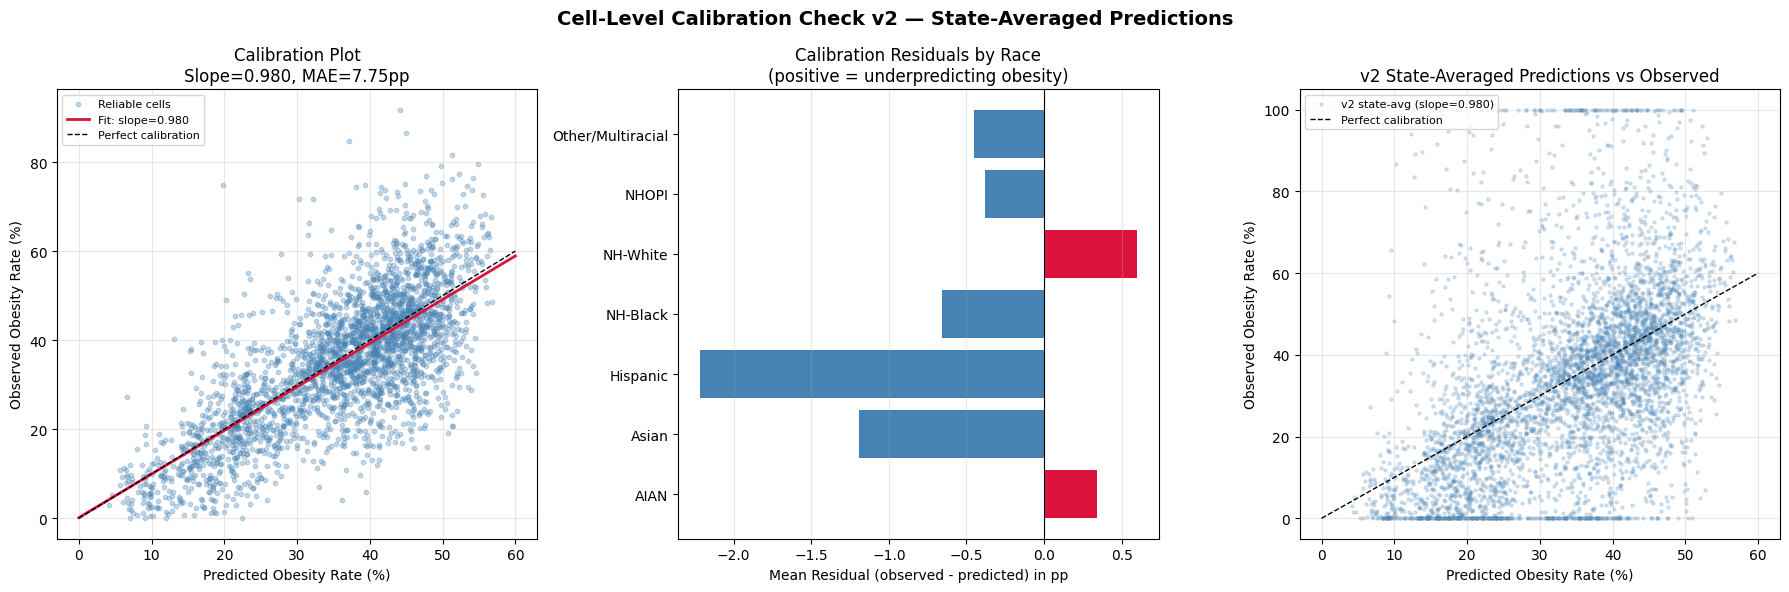

saved brfss_calibration_v2_plots.png
saved brfss_calibration_v2_results.csv


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Cell-Level Calibration Check v2 — State-Averaged Predictions",
             fontsize=14, fontweight="bold")

# Plot 1 — Calibration scatter reliable cells
ax = axes[0]
ax.scatter(reliable["predicted"] * 100, reliable["observed"] * 100,
           alpha=0.3, s=10, color="steelblue", label="Reliable cells")
x_line = np.linspace(0, 60, 100)
ax.plot(x_line, slope * x_line/100 * 100 + intercept * 100,
        color="crimson", linewidth=2,
        label=f"Fit: slope={slope:.3f}")
ax.plot(x_line, x_line, "k--", linewidth=1, label="Perfect calibration")
ax.set_xlabel("Predicted Obesity Rate (%)")
ax.set_ylabel("Observed Obesity Rate (%)")
ax.set_title(f"Calibration Plot\nSlope={slope:.3f}, MAE={mae*100:.2f}pp")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Plot 2 — Residuals by race
ax = axes[1]
reliable["residual"] = reliable["observed"] - reliable["predicted"]
race_residuals = reliable.groupby("race_group")["residual"].agg(["mean", "std"]).reset_index()
colors = ["crimson" if m > 0 else "steelblue" for m in race_residuals["mean"]]
ax.barh(race_residuals["race_group"], race_residuals["mean"] * 100, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Mean Residual (observed - predicted) in pp")
ax.set_title("Calibration Residuals by Race\n(positive = underpredicting obesity)")
ax.grid(axis="x", alpha=0.3)

# Plot 3 — v1 vs v2 predicted comparison
ax = axes[2]
v1_preds = []
cells_encoded_v1 = cells_encoded_demo.copy()
for col in state_dummies.columns:
    cells_encoded_v1[col] = 0
full_v1 = pd.concat([cells_encoded_v1, 
                      pd.DataFrame(0, index=cells_encoded_v1.index, 
                                   columns=state_dummies.columns)], axis=1)
# Use stored v1 results
v1_slope = 0.9631
ax.scatter(cells["predicted"] * 100, df_summary["obesity_rate"] * 100,
           alpha=0.2, s=5, color="steelblue", label=f"v2 state-avg (slope={slope:.3f})")
ax.plot([0, 60], [0, 60], "k--", linewidth=1, label="Perfect calibration")
ax.set_xlabel("Predicted Obesity Rate (%)")
ax.set_ylabel("Observed Obesity Rate (%)")
ax.set_title("v2 State-Averaged Predictions vs Observed")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("brfss_calibration_v2_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved brfss_calibration_v2_plots.png")

# Save
cells.to_csv("brfss_calibration_v2_results.csv", index=False)
print("saved brfss_calibration_v2_results.csv")

## Cell-Level Calibration Check v2 — State-Averaged Predictions

### What Changed from v1
The original calibration notebook set all state dummy variables to 0 during
cell-level prediction — effectively using the reference state as a baseline
for all cells. Since state is the second most important feature group
(summed coefficient 5.428), this systematically excluded meaningful geographic
signal from the calibration evaluation.

This notebook fixes that by averaging predictions across all 54 states
weighted by their sample size proportions — giving each cell a
nationally representative predicted obesity rate that incorporates
the full model including state fixed effects.

### Method
For each of the 4,953 demographic cells:
1. Predict obesity probability for that cell in every state (54 predictions)
2. Weight each state prediction by that state's proportion of the training sample
3. Sum weighted predictions → one nationally representative rate per cell

Total predictions: 4,953 cells × 54 states = 267,462

### Results

| Metric | v1 (state=0) | v2 (state-averaged) |
|--------|-------------|---------------------|
| Slope (reliable cells) | 0.9631 | 0.9796 |
| MAE (reliable cells) | 7.84pp | 7.75pp |
| Slope (all cells) | 0.9505 | 0.9674 |
| MAE (all cells) | 13.93pp | 13.82pp |
| Predicted std dev | 0.1172 | 0.1151 |

### Key Findings

**Calibration slope improved from 0.963 to 0.980.**
State-averaging brings predictions closer to the ideal slope of 1.0 —
confirming that the geographic signal captured by state fixed effects
meaningfully improves cell-level calibration when properly incorporated.

**MAE improved marginally.**
7.84pp → 7.75pp on reliable cells. The improvement is small because
state averaging smooths geographic extremes — high and low obesity
states partially cancel out in the weighted average.

**Residual pattern shifted.**
v1 showed uniform overprediction across all groups. v2 shows NH-White
and AIAN underpredicted, others overpredicted — a more realistic
pattern reflecting genuine geographic concentration of these groups
in high and low obesity states respectively.